In [1]:
import sys
import os

# Kaynak dosyaların bulunduğu klasörü path'e ekle
sys.path.insert(0, os.path.abspath("../"))  # Gerekirse klasör yolunu buraya yaz

from src.models.preprocessing import (
    load_raw_data,
    prepare_features_and_labels,
    Preprocessor,
    l2_normalize_rows,
    get_train_test_split,
    get_kfold_splits,
    build_url_feature_dataframe,
    stratified_sample
) #Burada src klasöründeki preprocessing modülünden gerekli fonksiyonları import ediyoruz. 
#İşlemler modülde yapılacak ve bu fonksiyonlar burada kullanılacak.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("✅ Tüm modüller başarıyla import edildi.")

✅ Tüm modüller başarıyla import edildi.


In [2]:
CSV_PATH      = "../data/raw/malicious_phish.csv"        # ← kendi yolun
LABEL_COLUMN  = "label"           # ← kendi label sütunun
POSITIVE_LABEL = "positive"       # ← binary ise doldur, değilse None
NEGATIVE_LABEL = "negative"       # ← binary ise doldur, değilse None

df = load_raw_data(CSV_PATH)
print(f"✅ Veri yüklendi: {df.shape}")
display(df.head())

✅ Veri yüklendi: (651191, 2)


,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


In [3]:
df_features = build_url_feature_dataframe(df, url_column="url")
display(df_features.head())

⏳ URL feature extraction çalışıyor...
✅ Feature extraction tamamlandı: (651191, 15)
   Sütunlar: ['url_len', 'dot_count', 'slash_count', 'dash_count', 'digit_count', 'letter_count', 'has_https', 'has_http', 'has_at', 'has_ip', 'has_suspicious', 'tld_len', 'subdomain_count', 'special_ratio', 'type']


,url_len,dot_count,slash_count,dash_count,digit_count,letter_count,has_https,has_http,has_at,has_ip,has_suspicious,tld_len,subdomain_count,special_ratio,type
0,16,2,0,1,0,13,0,0,0,0,0,2,1,0.000000,phishing
1,35,2,2,0,1,29,0,0,0,0,0,3,0,0.000000,benign
2,31,2,3,0,1,25,0,0,0,0,0,3,0,0.000000,benign
3,88,3,3,1,7,63,0,1,0,0,0,2,1,0.102273,defacement
4,235,2,3,1,22,199,0,1,0,0,0,3,0,0.029787,defacement


In [4]:
SAMPLE_PER_CLASS = 500
RANDOM_STATE     = 42

df_sampled = stratified_sample(
    df_features,
    label_column="type",
    n_per_class=SAMPLE_PER_CLASS,
    random_state=RANDOM_STATE,
)

print(f"Örneklenmiş shape: {df_sampled.shape}")
print(df_sampled["type"].value_counts())

Örneklenmiş shape: (2000, 15)
type
phishing      500
benign        500
defacement    500
malware       500
Name: count, dtype: int64


In [5]:
# Multi-class → positive/negative_label = None
X_raw, y = prepare_features_and_labels(
    df_sampled,
    label_column="type",
    positive_label=None,
    negative_label=None,
)

print(f"X shape : {X_raw.shape}")
print(f"y shape : {y.shape}")
print(f"Dağılım : {dict(zip(*np.unique(y, return_counts=True)))}")

ℹ️  Otomatik etiket haritası: {'benign': 0, 'defacement': 1, 'malware': 2, 'phishing': 3}
X shape : (2000, 14)
y shape : (2000,)
Dağılım : {np.int64(0): np.int64(500), np.int64(1): np.int64(500), np.int64(2): np.int64(500), np.int64(3): np.int64(500)}


In [6]:
X_train_raw, X_test_raw, y_train, y_test = get_train_test_split(
    X_raw, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=True,
)

print(f"Train : {X_train_raw.shape}")
print(f"Test  : {X_test_raw.shape}")
print(f"Train dağılımı: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test  dağılımı: {dict(zip(*np.unique(y_test,  return_counts=True)))}")

Train : (1600, 14)
Test  : (400, 14)
Train dağılımı: {np.int64(0): np.int64(400), np.int64(1): np.int64(400), np.int64(2): np.int64(400), np.int64(3): np.int64(400)}
Test  dağılımı: {np.int64(0): np.int64(100), np.int64(1): np.int64(100), np.int64(2): np.int64(100), np.int64(3): np.int64(100)}


In [7]:
N_PCA = None

prep = Preprocessor(
    apply_standard=False,
    apply_minmax=True,
    apply_l2=True,
    n_pca_components=N_PCA,
)

X_train = prep.fit_transform(X_train_raw)
X_test  = prep.transform(X_test_raw)

print(f"X_train → shape: {X_train.shape}  min: {X_train.min():.3f}  max: {X_train.max():.3f}")
print(f"X_test  → shape: {X_test.shape}   min: {X_test.min():.3f}  max: {X_test.max():.3f}")

if prep.pca is not None:
    ev = prep.pca.explained_variance_ratio_
    print(f"PCA açıklanan varyans: {ev.round(3)}  → Toplam: {ev.sum():.3f}")

X_train → shape: (1600, 14)  min: 0.000  max: 0.999
X_test  → shape: (400, 14)   min: -0.002  max: 0.994


In [8]:
print(f"{'Fold':<6} {'Train':<8} {'Test':<8} {'Train dağılımı'}")
print("-" * 52)

for fold, (Xf_tr, Xf_te, yf_tr, yf_te) in enumerate(
    get_kfold_splits(X_raw, y, n_splits=5, random_state=RANDOM_STATE), 1
):
    p = Preprocessor(apply_standard=True, apply_minmax=True, apply_l2=True)
    Xf_tr = p.fit_transform(Xf_tr)
    Xf_te = p.transform(Xf_te)
    dist  = dict(zip(*np.unique(yf_tr, return_counts=True)))
    print(f"{fold:<6} {len(yf_tr):<8} {len(yf_te):<8} {dist}")

Fold   Train    Test     Train dağılımı
----------------------------------------------------
1      1600     400      {np.int64(0): np.int64(400), np.int64(1): np.int64(400), np.int64(2): np.int64(400), np.int64(3): np.int64(400)}
2      1600     400      {np.int64(0): np.int64(400), np.int64(1): np.int64(400), np.int64(2): np.int64(400), np.int64(3): np.int64(400)}
3      1600     400      {np.int64(0): np.int64(400), np.int64(1): np.int64(400), np.int64(2): np.int64(400), np.int64(3): np.int64(400)}
4      1600     400      {np.int64(0): np.int64(400), np.int64(1): np.int64(400), np.int64(2): np.int64(400), np.int64(3): np.int64(400)}
5      1600     400      {np.int64(0): np.int64(400), np.int64(1): np.int64(400), np.int64(2): np.int64(400), np.int64(3): np.int64(400)}


In [9]:

# Klasörü oluştur (yoksa)
os.makedirs("../data/processed", exist_ok=True)

# Kaydet
np.save("../data/processed/X_train.npy", X_train)
np.save("../data/processed/X_test.npy",  X_test)
np.save("../data/processed/y_train.npy", y_train)
np.save("../data/processed/y_test.npy",  y_test)

print("✅ Kaydedildi:")
print(f"   data/processed/X_train.npy → {X_train.shape}")
print(f"   data/processed/X_test.npy  → {X_test.shape}")
print(f"   data/processed/y_train.npy → {y_train.shape}")
print(f"   data/processed/y_test.npy  → {y_test.shape}")

✅ Kaydedildi:
   data/processed/X_train.npy → (1600, 14)
   data/processed/X_test.npy  → (400, 14)
   data/processed/y_train.npy → (1600,)
   data/processed/y_test.npy  → (400,)


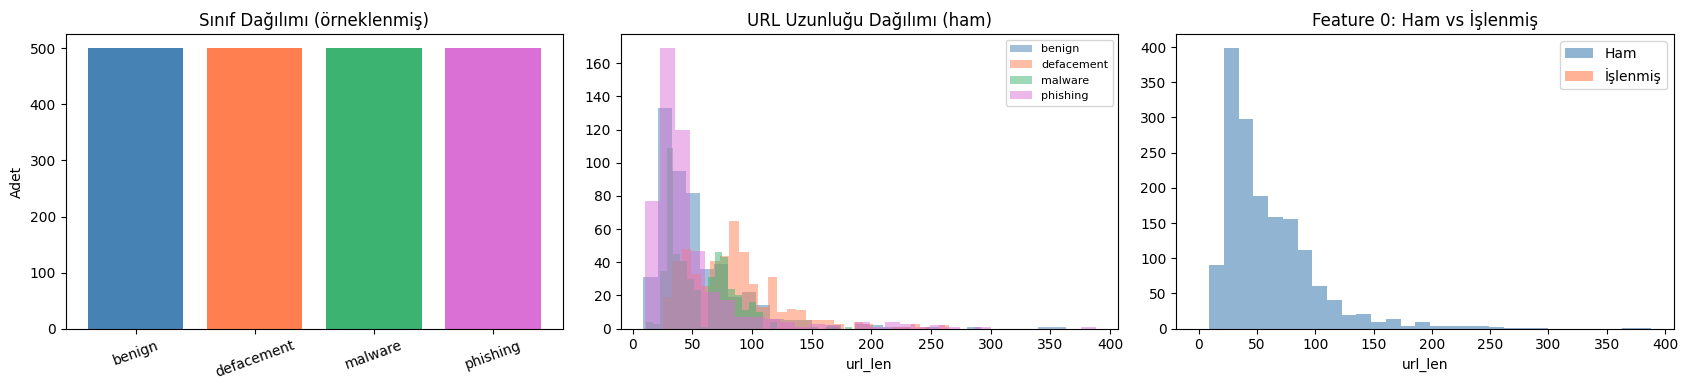

In [10]:
CLASS_NAMES = ["benign", "defacement", "malware", "phishing"]
COLORS      = ["steelblue", "coral", "mediumseagreen", "orchid"]

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# 1) Sınıf dağılımı
counts = [np.sum(y == i) for i in range(len(CLASS_NAMES))]
axes[0].bar(CLASS_NAMES, counts, color=COLORS)
axes[0].set_title("Sınıf Dağılımı (örneklenmiş)")
axes[0].set_ylabel("Adet")
plt.setp(axes[0].get_xticklabels(), rotation=20)

# 2) URL uzunluğu — sınıfa göre
for i, (cls, col) in enumerate(zip(CLASS_NAMES, COLORS)):
    axes[1].hist(X_raw[y == i, 0], bins=30, alpha=0.5, label=cls, color=col)
axes[1].set_title("URL Uzunluğu Dağılımı (ham)")
axes[1].set_xlabel("url_len")
axes[1].legend(fontsize=8)

# 3) İşlenmiş veri — feature 0 dağılımı (ham vs işlenmiş karşılaştırma)
axes[2].hist(X_train_raw[:, 0], bins=30, alpha=0.6, label="Ham", color="steelblue")
axes[2].hist(X_train[:, 0],     bins=30, alpha=0.6, label="İşlenmiş", color="coral")
axes[2].set_title("Feature 0: Ham vs İşlenmiş")
axes[2].set_xlabel("url_len")
axes[2].legend()

plt.tight_layout()
plt.show()

In [11]:
print("=" * 55)
print("      PREPROCESSİNG ÖZETİ — Malicious URLs")
print("=" * 55)
print(f"  Toplam URL         : {len(df):,}")
print(f"  Örneklenmiş        : {len(df_sampled):,}  ({SAMPLE_PER_CLASS}/sınıf)")
print(f"  Feature sayısı     : {X_raw.shape[1]}  (lexical)")
print(f"  Train              : {X_train.shape}")
print(f"  Test               : {X_test.shape}")
print(f"  StandardScaler     : {'✅' if prep.std_scaler else '—'}")
print(f"  PCA                : {'✅ (' + str(N_PCA) + ' bileşen)' if prep.pca else '—'}")
print(f"  MinMaxScaler       : {'✅' if prep.mm_scaler else '—'}")
print(f"  L2 Norm            : {'✅' if prep.apply_l2 else '—'}")
print("=" * 55)
print(f"  Train dağılımı: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"  Test  dağılımı: {dict(zip(*np.unique(y_test,  return_counts=True)))}")

      PREPROCESSİNG ÖZETİ — Malicious URLs
  Toplam URL         : 651,191
  Örneklenmiş        : 2,000  (500/sınıf)
  Feature sayısı     : 14  (lexical)
  Train              : (1600, 14)
  Test               : (400, 14)
  StandardScaler     : —
  PCA                : —
  MinMaxScaler       : ✅
  L2 Norm            : ✅
  Train dağılımı: {np.int64(0): np.int64(400), np.int64(1): np.int64(400), np.int64(2): np.int64(400), np.int64(3): np.int64(400)}
  Test  dağılımı: {np.int64(0): np.int64(100), np.int64(1): np.int64(100), np.int64(2): np.int64(100), np.int64(3): np.int64(100)}
